In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

import yaml

sys.path.insert(0, str(Path().absolute().parent.parent.parent))

In [2]:
import numpy as np
import pandas as pd

import matplotlib
import shutil

# Manually configure the path to the LaTeX executable from your conda env
# Note: You might need to adjust the path slightly based on your installation
latex_path = shutil.which("latex")  # This finds latex in your current PATH

if latex_path:
    matplotlib.rcParams['text.latex.preamble'] = ''
    matplotlib.rcParams['text.usetex'] = True
    matplotlib.rcParams['pgf.texsystem'] = 'pdflatex'
    matplotlib.rcParams['pgf.rcfonts'] = False
    matplotlib.rcParams['pgf.preamble'] = ''
    # Point to the TeX programs in the same directory
    matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    print("✅ Matplotlib's LaTeX path has been configured.")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook", font_scale=1.25)

✅ Matplotlib's LaTeX path has been configured.


In [3]:
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
# sns.set_theme(rc={'text.usetex' : True})
import numpy as np
import pandas as pd
from test.lib.files_utils import SimulationOutput, LisLoader, ISOTOPES, func

In [4]:
lis_loader = LisLoader(Path().absolute().parent / 'data' / 'LIS_Default2020_Proton')

In [5]:
output_files = Path().absolute().parent / 'data' / 'uncertainty' / 'outputs'
rows = []
for of in sorted(output_files.rglob('*.yaml')):
    date, _, part = of.parent.name.split('_')
    print(date, part)
    outputs = SimulationOutput(SimulationOutput.from_yaml(yaml.load(of.read_text(), Loader=yaml.CLoader)))
    fluxes = outputs.modulate(lis_loader)
    for i, (out, flux) in enumerate(zip(outputs, fluxes)):
        for j, (r, f, e) in enumerate(zip(*flux.rig_flux, flux.error)):
            vars, evs, nbins = 0, 0, 0
            for iso, ot in out.items():
                lis = lis_loader[iso]
                in_rig, out_rig, out_dist, n_part = ot.input_rig[j:j + 1], ot.output_rig[j], ot.output_dist[j], \
                    ot.n_particles[j]

                lis_flux_en_out = func.lin_log_interpolation(lis.energy.to_rigidity(iso), lis.flux, out_rig)

                A, B, N = (lis_flux_en_out / out_rig ** 2), out_dist, n_part
                C = func.d_rig_to_en(in_rig.to_energy(iso), in_rig, iso.Z, iso.A)
                vars += C ** 2 * (np.sum(B * A ** 2) - np.sum(B * A) ** 2 / N)
                evs += C * np.sum(B * A)

                nbins = np.trim_zeros(out_dist, 'f').shape[0]

            rel_err = np.sqrt(np.sum(vars)) / np.sum(evs)

            assert np.allclose(float(e), float(rel_err), rtol=0.001), (float(e), float(rel_err))

            rows.append([date, part, i, r, f, rel_err, nbins])

20111116 1024
20111116 16384
20111116 2048
20111116 4096
20111116 512
20111116 8192
20140917 1024
20140917 16384
20140917 2048
20140917 4096
20140917 512
20140917 8192
20150907 1024
20150907 16384
20150907 2048
20150907 4096
20150907 512
20150907 8192
20160827 1024
20160827 16384
20160827 2048
20160827 4096
20160827 512
20160827 8192
20170623 1024
20170623 16384
20170623 2048
20170623 4096
20170623 512
20170623 8192
20180929 1024
20180929 16384
20180929 2048
20180929 4096
20180929 512
20180929 8192


In [6]:
rows[0]

['20111116',
 '1024',
 0,
 np.float64(0.137352),
 np.float64(8.789038645180593),
 RigidityVec(0.03240063),
 170]

In [7]:
df = pd.DataFrame(rows, columns=['date', 'part', 'param', 'rig', 'flux', 'rel_err', 'nbins'])
df['part'] = df['part'].astype(int)
df['param'] = df['param'].astype(int)
df['rig'] = df['rig'].astype(float)
df['flux'] = df['flux'].astype(float)
df['rel_err'] = df['rel_err'].astype(float)
df['nbins'] = df['nbins'].astype(int)
df.sort_values(df.columns.to_list(), inplace=True)
df.to_csv('uncertainty.csv', index=False)
df

,date,part,param,rig,flux,rel_err,nbins
2520,20111116,512,0,0.137352,8.814842,0.043516,165
2521,20111116,512,0,0.172913,16.243759,0.045095,213
2522,20111116,512,0,0.218475,31.874788,0.046871,170
2523,20111116,512,0,0.276171,63.252443,0.042522,167
2524,20111116,512,0,0.349845,120.453813,0.039531,156
...,...,...,...,...,...,...,...
20155,20180929,16384,29,16.712000,6.685135,0.000559,18
20156,20180929,16384,29,26.021400,1.972927,0.000366,12
20157,20180929,16384,29,40.727500,0.563557,0.000236,10
20158,20180929,16384,29,64.031400,0.157985,0.000173,6


In [51]:
df2 = df.copy()
df2 = df2.groupby(['date', 'part', 'rig']).agg(nbins=('nbins', 'max'), flux_mean=('flux', 'mean'),
                                               flux_std=('flux', 'std'),
                                               flux_rel=('flux', lambda x: x.std() / x.mean()),
                                               rel_err=('rel_err', lambda x: x.sample(1)),
                                               # rel_err=('rel_err', lambda x: x.max()),
                                               rel_err_var=('rel_err', 'var')).reset_index()

df2['flux_ratio'] = df2['flux_rel'] / df2['rel_err']
df2['flux_diff'] = (df2['flux_rel'] - df2['rel_err']) / df2['flux_rel']

df2['nbins_norm'] = df2['nbins'] / df2['nbins'].max()

df2

,date,part,rig,nbins,flux_mean,flux_std,flux_rel,rel_err,rel_err_var,flux_ratio,flux_diff,nbins_norm
0,20111116,512,0.137352,199,8.483122,0.495872,0.058454,0.041347,1.082434e-05,1.413754,0.292663,0.665552
1,20111116,512,0.172913,213,16.956072,0.769877,0.045404,0.045095,7.850442e-06,1.006857,0.006810,0.712375
2,20111116,512,0.218475,205,33.117663,1.447268,0.043701,0.045065,6.732372e-06,0.969727,-0.031218,0.685619
3,20111116,512,0.276171,188,64.766956,2.594780,0.040063,0.039230,9.827477e-06,1.021240,0.020798,0.628763
4,20111116,512,0.349845,200,123.844554,4.612447,0.037244,0.042368,3.037575e-06,0.879066,-0.137571,0.668896
...,...,...,...,...,...,...,...,...,...,...,...,...
751,20180929,16384,16.712000,23,6.691377,0.004146,0.000620,0.000546,2.379709e-11,1.133991,0.118159,0.076923
752,20180929,16384,26.021400,15,1.972848,0.000603,0.000306,0.000362,5.856653e-12,0.845578,-0.182623,0.050167
753,20180929,16384,40.727500,10,0.563495,0.000143,0.000254,0.000237,3.577150e-12,1.074966,0.069738,0.033445
754,20180929,16384,64.031400,7,0.157989,0.000030,0.000190,0.000174,1.169181e-12,1.093956,0.085887,0.023411


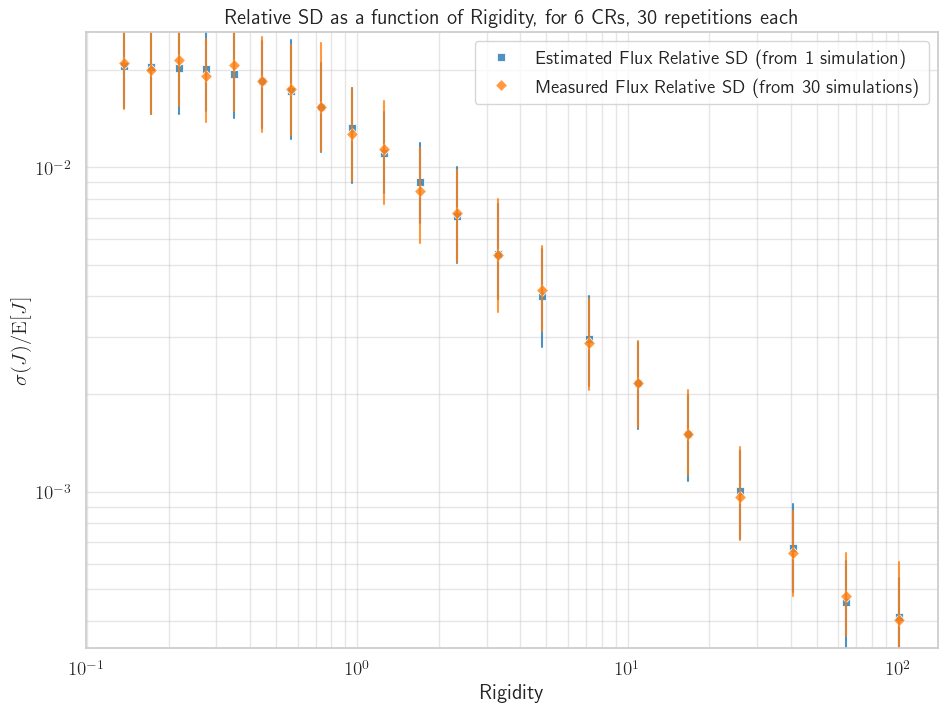

In [52]:
fig, ax = plt.subplots(figsize=(11, 8))

ax.set(xscale='log', yscale='log', xlabel='Rigidity', ylabel=r'$\sigma(J)/\mathrm{E}[J]$',
       title='Relative SD as a function of Rigidity, for 6 CRs, 30 repetitions each')

axx = sns.lineplot(
    df2.query('(rig<1001) & (part > 1)'),
    x='rig',
    y='rel_err',
    # hue='date',
    errorbar=('ci', 100),
    err_style='bars', marker='s', linestyle='', alpha=0.8,
    # marker='s',
    label='Estimated Flux Relative SD (from 1 simulation)',
    ax=ax
)

axx = sns.lineplot(
    df2.query('(rig<1001) & (part > 1)'),
    x='rig',
    y='flux_rel',
    # hue='date',
    errorbar=('ci', 100),
    err_style='bars', marker='D', linestyle='', alpha=0.8,
    # marker='D',
    label='Measured Flux Relative SD (from 30 simulations)',
    ax=ax
)

ax.grid(True, which="both", ls="-", alpha=0.5)
# ax.axhline(y=0.02, color='k', ls='--')
plt.savefig('plots/comparison.pdf', bbox_inches='tight')
plt.show()

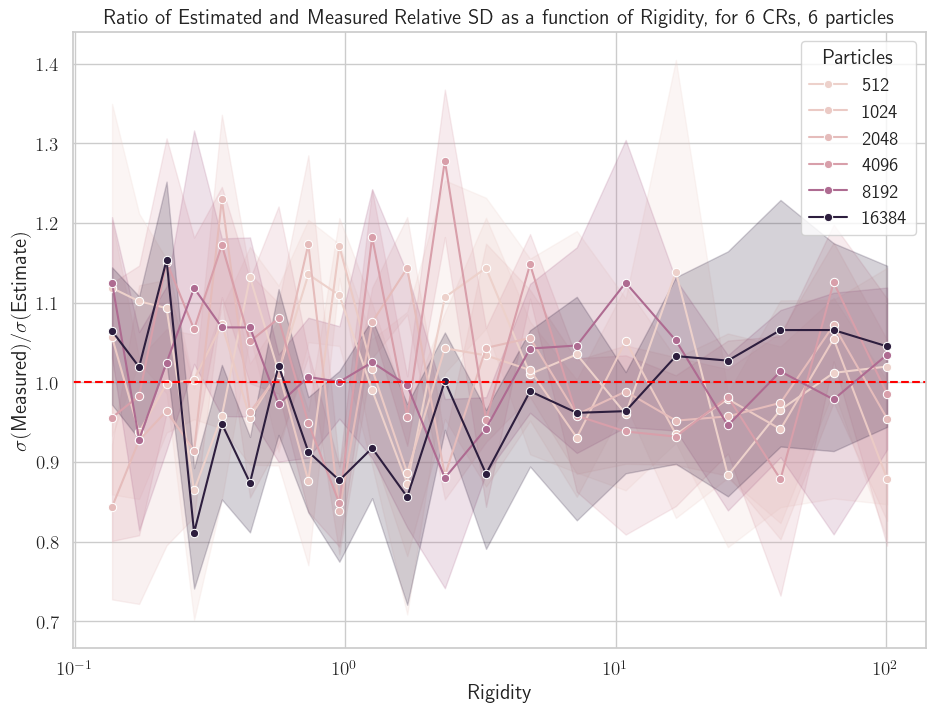

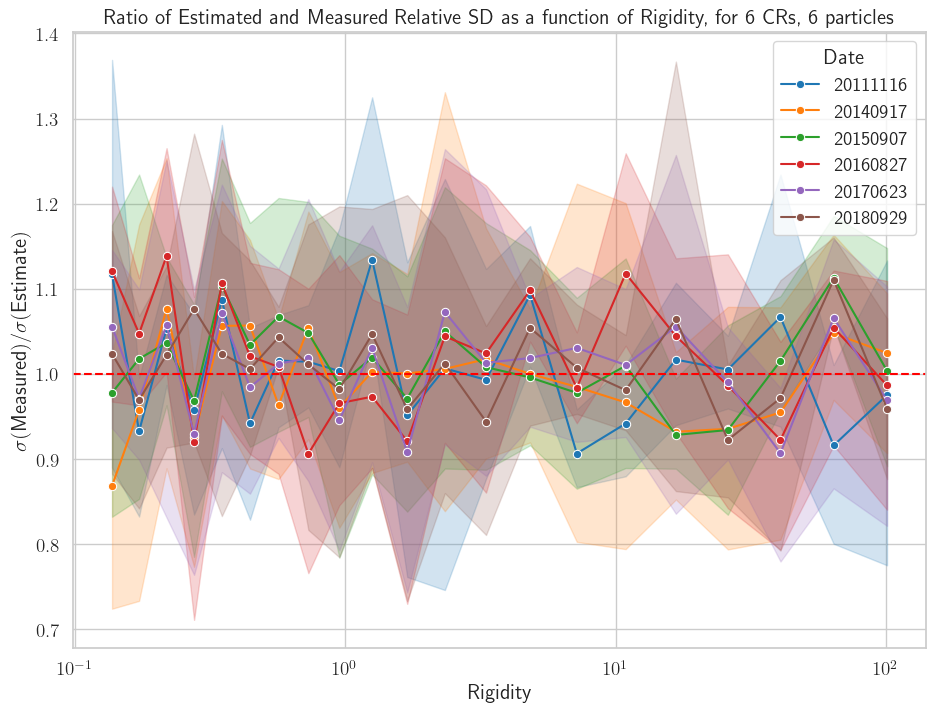

In [53]:
fig, ax = plt.subplots(figsize=(11, 8))
axx = sns.lineplot(
    df2.query('(rig<1001) & (part > 1) '),
    x='rig',
    y='flux_ratio',
    hue='part',
    errorbar=('ci', 100),
    marker='o',
    ax=ax
)

axx.set(xscale='log', xlabel='Rigidity', ylabel=r'$\sigma(\text{Measured}) / \sigma(\text{Estimate})$',
        title='Ratio of Estimated and Measured Relative SD as a function of Rigidity, for 6 CRs, 6 particles')
ax.axhline(1, color='red', ls='--')

plt.legend().set_title('Particles')

plt.savefig('plots/ratio_part.pdf', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(11, 8))
axx = sns.lineplot(
    df2.query('(rig<1001) & (part > 1) '),
    x='rig',
    y='flux_ratio',
    hue='date',
    errorbar=('ci', 100),
    marker='o',
    ax=ax
)

axx.set(xscale='log', xlabel='Rigidity', ylabel=r'$\sigma(\text{Measured}) / \sigma(\text{Estimate})$',
        title='Ratio of Estimated and Measured Relative SD as a function of Rigidity, for 6 CRs, 6 particles')
ax.axhline(1, color='red', ls='--')

plt.legend().set_title('Date')

plt.savefig('plots/ratio_date.pdf', bbox_inches='tight')
plt.show()

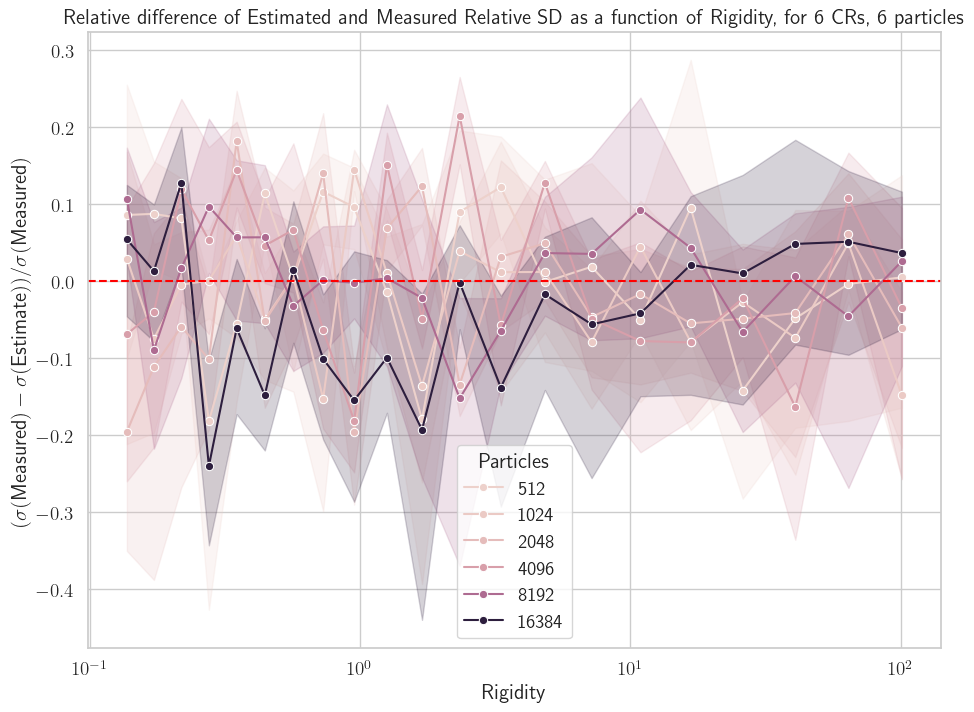

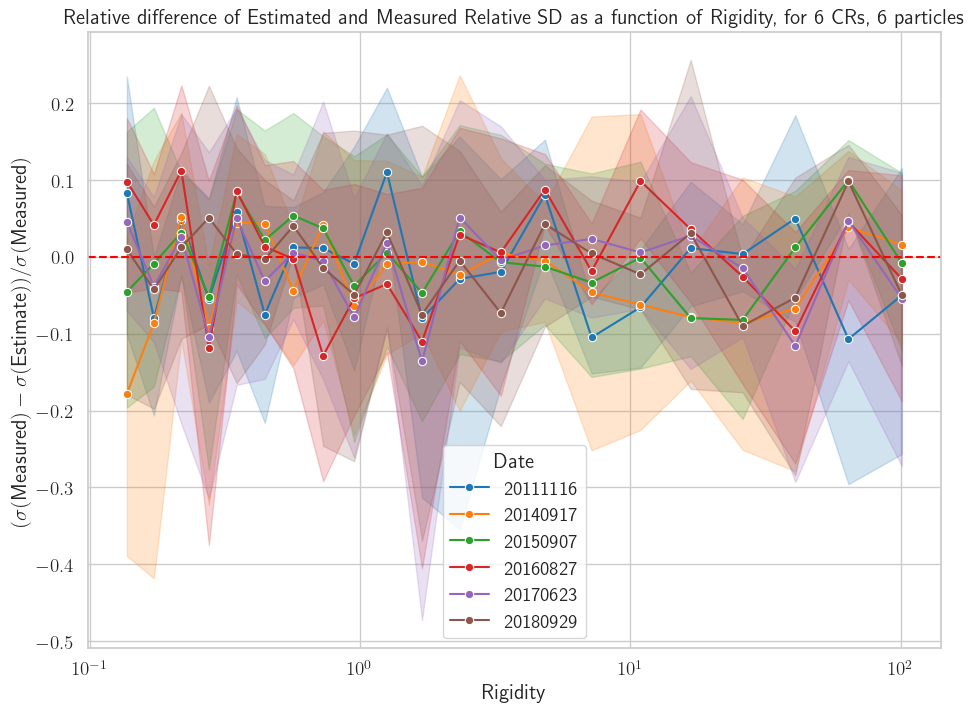

In [54]:
fig, ax = plt.subplots(figsize=(11, 8))
axx = sns.lineplot(
    df2.query('(rig<1001) & (part > 1) '),
    x='rig',
    y='flux_diff',
    hue='part',
    errorbar=('ci', 100),
    marker='o',
    ax=ax
)

axx.set(xscale='log', xlabel='Rigidity',
        ylabel=r'$(\sigma(\text{Measured}) - \sigma(\text{Estimate})) / \sigma(\text{Measured})$',
        title='Relative difference of Estimated and Measured Relative SD as a function of Rigidity, for 6 CRs, 6 particles')
ax.axhline(0, color='red', ls='--')

plt.legend().set_title('Particles')

plt.savefig('plots/difference_part.pdf', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(11, 8))
axx = sns.lineplot(
    df2.query('(rig<1001) & (part > 1) '),
    x='rig',
    y='flux_diff',
    hue='date',
    errorbar=('ci', 100),
    marker='o',
    ax=ax
)

axx.set(xscale='log', xlabel='Rigidity',
        ylabel=r'$(\sigma(\text{Measured}) - \sigma(\text{Estimate})) / \sigma(\text{Measured})$',
        title='Relative difference of Estimated and Measured Relative SD as a function of Rigidity, for 6 CRs, 6 particles')
ax.axhline(0, color='red', ls='--')

plt.legend().set_title('Date')

plt.savefig('plots/difference_date.pdf', bbox_inches='tight')
plt.show()

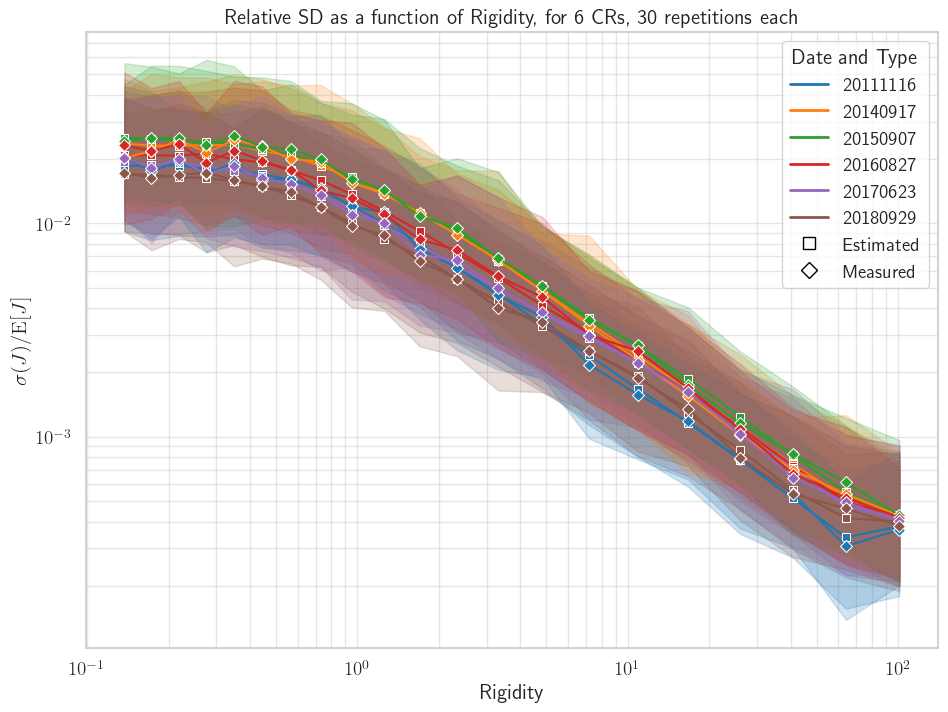

In [55]:
fig, ax = plt.subplots(figsize=(11, 8))

ax.set(xscale='log', yscale='log', xlabel='Rigidity', ylabel=r'$\sigma(J)/\mathrm{E}[J]$',
       title='Relative SD as a function of Rigidity, for 6 CRs, 30 repetitions each')

axx = sns.lineplot(
    df2.query('(rig<1001) & (part > 1)'),
    x='rig',
    y='rel_err',
    hue='date',
    errorbar=('ci', 100),
    marker='s',
    ax=ax
)

axx = sns.lineplot(
    df2.query('(rig<1001) & (part > 1)'),
    x='rig',
    y='flux_rel',
    hue='date',
    errorbar=('ci', 100),
    marker='D',
    ax=ax
)

ax.grid(True, which="both", ls="-", alpha=0.5)

handles, labels = axx.get_legend_handles_labels()
date_handles = []
date_labels = []

for i, label in enumerate(labels[:len(labels) // 2]):
    date_handles.append(plt.Line2D([0], [0], color=handles[i].get_color(), lw=2))
    date_labels.append(label)

experimental_handle = plt.Line2D([0], [0], marker='s', fillstyle='none', color='k', label='Estimated', markersize=8,
                                 linestyle='None')
measured_handle = plt.Line2D([0], [0], marker='D', fillstyle='none', color='k', label='Measured', markersize=8,
                             linestyle='None')

custom_handles = date_handles + [experimental_handle, measured_handle]
custom_labels = date_labels + ['Estimated', 'Measured']

ax.legend(custom_handles, custom_labels, title='Date and Type', loc='best')

plt.savefig('plots/comparison_date.pdf', bbox_inches='tight')
plt.show()

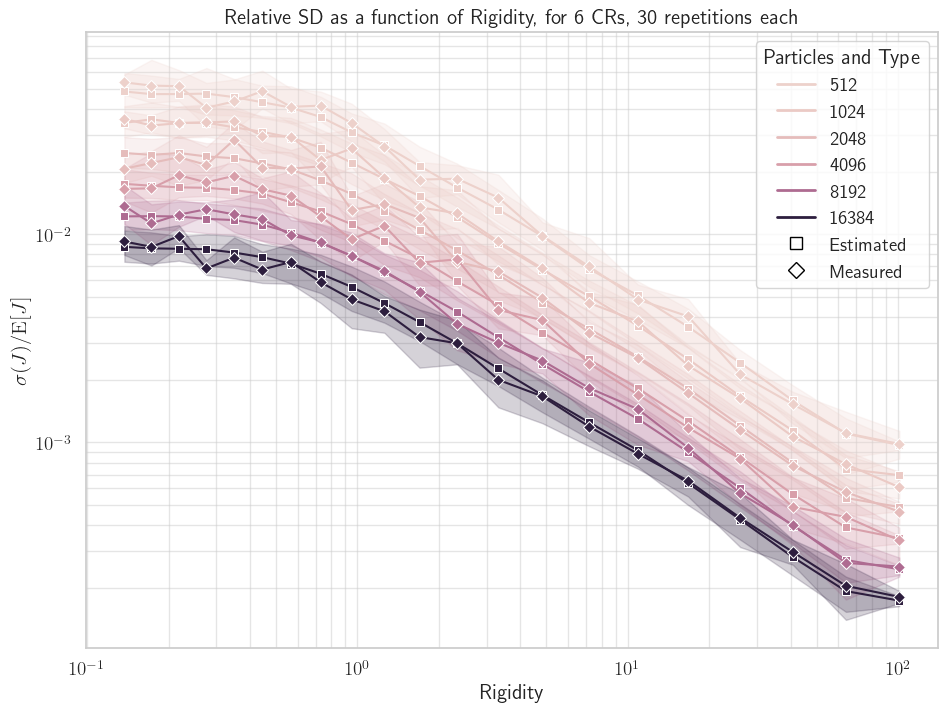

In [56]:
fig, ax = plt.subplots(figsize=(11, 8))

ax.set(xscale='log', yscale='log', xlabel='Rigidity', ylabel=r'$\sigma(J)/\mathrm{E}[J]$',
       title='Relative SD as a function of Rigidity, for 6 CRs, 30 repetitions each')

axx = sns.lineplot(
    df2.query('(rig<1001) & (part > 1)'),
    x='rig',
    y='rel_err',
    hue='part',
    errorbar=('ci', 100),
    marker='s',
    ax=ax
)

axx = sns.lineplot(
    df2.query('(rig<1001) & (part > 1)'),
    x='rig',
    y='flux_rel',
    hue='part',
    errorbar=('ci', 100),
    marker='D',
    ax=ax
)

ax.grid(True, which="both", ls="-", alpha=0.5)

handles, labels = axx.get_legend_handles_labels()
date_handles = []
date_labels = []

for i, label in enumerate(labels[:len(labels) // 2]):
    date_handles.append(plt.Line2D([0], [0], color=handles[i].get_color(), lw=2))
    date_labels.append(label)

experimental_handle = plt.Line2D([0], [0], marker='s', fillstyle='none', color='k', label='Estimated', markersize=8,
                                 linestyle='None')
measured_handle = plt.Line2D([0], [0], marker='D', fillstyle='none', color='k', label='Measured', markersize=8,
                             linestyle='None')

custom_handles = date_handles + [experimental_handle, measured_handle]
custom_labels = date_labels + ['Estimated', 'Measured']

ax.legend(custom_handles, custom_labels, title='Particles and Type', loc='best')

plt.savefig('plots/comparison_part.pdf', bbox_inches='tight')
plt.show()

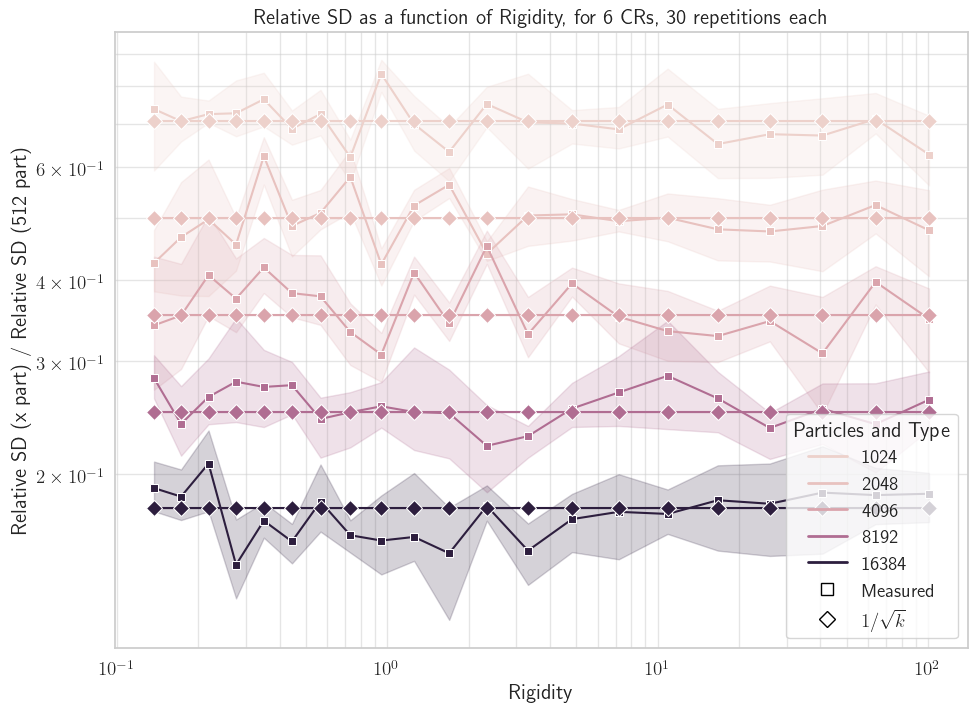

In [57]:
df_ = pd.merge(
    df2.query('part == 512'),
    df2.query('part != 512'),
    on=['date', 'rig'],
)
# df_['ratio'] = df_['flux'] / df_['exetime_y']
df_['ratio_m'] = df_['flux_rel_y'] / df_['flux_rel_x']
df_['ratio_e'] = df_['rel_err_y'] / df_['rel_err_x']
df_['ratio_h'] = df_['flux_rel_y'] / df_['rel_err_x']
df_['exp_ratio'] = 1 / np.sqrt(df_['part_y'] / df_['part_x'])
df_.rename(columns={'part_y': 'part'}, inplace=True)

fig, ax = plt.subplots(figsize=(11, 8))

ax.set(xscale='log', yscale='log', xlabel='Rigidity', ylabel='Relative SD (x part) / Relative SD (512 part)',
       title='Relative SD as a function of Rigidity, for 6 CRs, 30 repetitions each')

axx = sns.lineplot(
    df_.query('(rig<1001) & (part > 1)'),
    x='rig',
    y='ratio_h',
    hue='part',
    errorbar=('ci', 100),
    marker='s',
    ax=ax
)

axx = sns.lineplot(
    df_.query('(rig<1001) & (part > 1)'),
    x='rig',
    y='exp_ratio',
    hue='part',
    # errorbar=('ci', 100),
    # palette=sns.color_palette(['r']),
    markersize=8,
    marker='D',
    ax=ax
)

ax.grid(True, which="both", ls="-", alpha=0.5)

handles, labels = axx.get_legend_handles_labels()
date_handles = []
date_labels = []

for i, label in enumerate(labels[:len(labels) // 2]):
    date_handles.append(plt.Line2D([0], [0], color=handles[i].get_color(), lw=2))
    date_labels.append(label)

experimental_handle = plt.Line2D([0], [0], marker='s', fillstyle='none', color='k', label='Estimated', markersize=8,
                                 linestyle='None')
measured_handle = plt.Line2D([0], [0], marker='D', fillstyle='none', color='k', label=r'$1/\sqrt{k}$', markersize=8,
                             linestyle='None')

custom_handles = date_handles + [experimental_handle, measured_handle]
custom_labels = date_labels + ['Measured', r'$1/\sqrt{k}$']

ax.legend(custom_handles, custom_labels, title='Particles and Type', loc='best')

plt.savefig('plots/part_scale.pdf', bbox_inches='tight')
plt.show()

In [27]:
def threshold(t):
    return np.sqrt(2) * (1.29 * t ** (-0.85)) / (t ** -0.85 + 1.5)


fig, ax = plt.subplots(figsize=(10, 9))
axx = sns.lineplot(
    df2.query('(rig<1001)'),
    x='rig',
    y='flux_ratio',
    hue='date',
    # errorbar=('ci', .05),
    err_style='bars', marker='o', linestyle='',
    ax=ax
)
sns.lineplot(
    x=df2.query('(rig<101)')['rig'],
    y=threshold(df2.query('(rig<101)')['rig']),
    color='k',
    label='old threshold',
    ax=ax,
)

sns.lineplot(
    df2,
    x='rig',
    y='nbins_norm',
    hue='date',
)
axx.set(xscale='log', yscale='log', xlabel='Energy', ylabel=r'(sigma sim) / (sigma pois)')
# axx.axhline(2*10**-2)

,date,part_x,rig,nbins_x,flux_mean_x,flux_std_x,flux_rel_x,rel_err_x,rel_err_var_x,flux_ratio_x,...,flux_std_y,flux_rel_y,rel_err_y,rel_err_var_y,flux_ratio_y,flux_diff_y,nbins_norm_y,ratio_m,ratio_e,exp_ratio
0,20111116,512,0.137352,199,8.483122,0.495872,0.058454,0.047329,1.082434e-05,1.235046,...,0.319529,0.037122,0.030372,1.655254e-06,1.222221,0.181817,0.665552,0.635060,0.641724,0.707107
1,20111116,512,0.137352,199,8.483122,0.495872,0.058454,0.047329,1.082434e-05,1.235046,...,0.159820,0.018732,0.022435,3.196730e-07,0.834949,-0.197679,0.725753,0.320453,0.474010,0.500000
2,20111116,512,0.137352,199,8.483122,0.495872,0.058454,0.047329,1.082434e-05,1.235046,...,0.142710,0.016604,0.015608,1.268229e-07,1.063852,0.060020,0.735786,0.284060,0.329770,0.353553
3,20111116,512,0.137352,199,8.483122,0.495872,0.058454,0.047329,1.082434e-05,1.235046,...,0.105195,0.012250,0.011104,3.023171e-08,1.103258,0.093593,0.769231,0.209572,0.234606,0.250000
4,20111116,512,0.137352,199,8.483122,0.495872,0.058454,0.047329,1.082434e-05,1.235046,...,0.075898,0.008828,0.007711,1.210869e-08,1.144878,0.126544,0.819398,0.151022,0.162916,0.176777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,20180929,512,100.934000,4,0.044028,0.000041,0.000941,0.000960,2.584260e-10,0.980457,...,0.000026,0.000601,0.000672,6.344319e-11,0.893847,-0.118760,0.016722,0.638500,0.700368,0.707107
626,20180929,512,100.934000,4,0.044028,0.000041,0.000941,0.000960,2.584260e-10,0.980457,...,0.000018,0.000416,0.000476,1.128917e-11,0.873813,-0.144410,0.013378,0.442107,0.496063,0.500000
627,20180929,512,100.934000,4,0.044028,0.000041,0.000941,0.000960,2.584260e-10,0.980457,...,0.000013,0.000296,0.000333,7.588913e-12,0.887248,-0.127081,0.016722,0.314269,0.347284,0.353553
628,20180929,512,100.934000,4,0.044028,0.000041,0.000941,0.000960,2.584260e-10,0.980457,...,0.000011,0.000258,0.000237,1.326152e-12,1.088535,0.081334,0.013378,0.274335,0.247097,0.250000


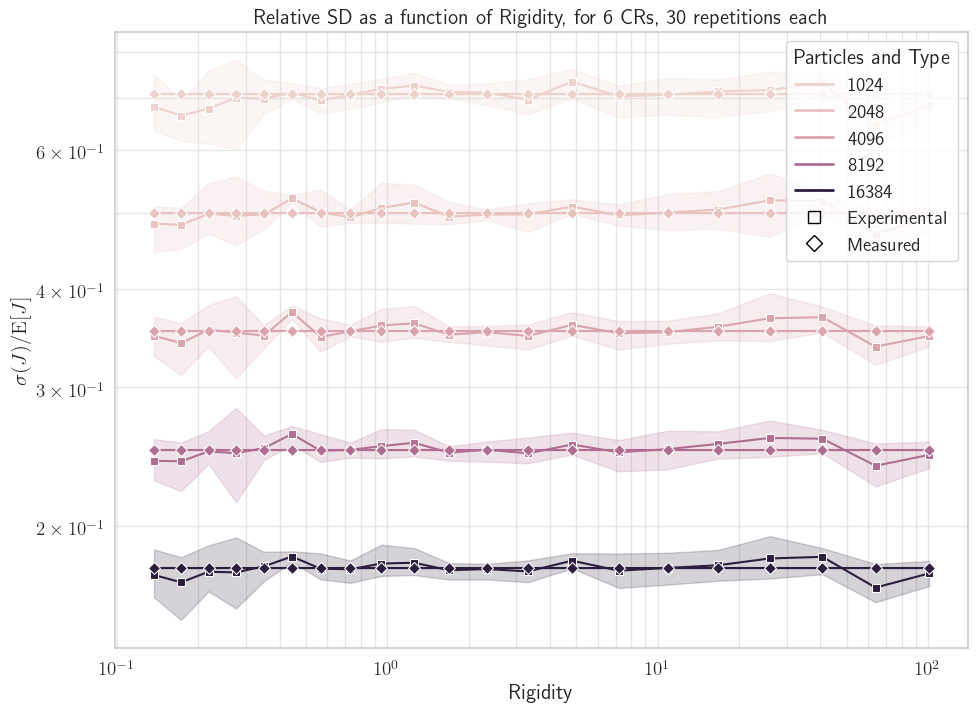

In [31]:
# fig, ax = plt.subplots(figsize=(10, 9))
#
# ax.set(xscale='log', xlabel='Rigidity', ylabel=r'$\sigma$')
#
# axx = sns.lineplot(
#     df2.query('(rig<1001) & (part > 1)'),
#     x='rig',
#     y='bias',
#     hue='part',
#     errorbar=('ci', 95),
#     # err_style='bars', marker='o', linestyle='',
#     marker='o',
#     ax=ax
# )
# # axx = sns.lineplot(
# #     df2.query('(rig<1001) & (part > 16000)'),
# #     x='rig',
# #     y='nbins_norm',
# #     # hue='date',
# #     errorbar=('ci', 95),
# #     # err_style='bars', marker='o', linestyle='',
# #     marker='o',
# #     ax=ax
# # )
#
# plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(15, 9))
axx = sns.boxplot(
    df2.query('(rig<1001)'),
    x='rig',
    y='flux_ratio_norm',
    hue='part',
    # errorbar=('ci', .05),
    # err_style='bars', marker='o', linestyle='',
    palette='muted',
    ax=ax
)

axx.set(xlabel='Energy', ylabel=r'(sigma sim) / (sigma pois)')
plt.xticks(rotation=90)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 9))
axx = sns.lineplot(
    df2.query('(rig<1001)'),
    x='rig',
    y='avg_ratio',
    hue='date',
    # errorbar=('ci', .05),
    err_style='bars', marker='o', linestyle='',
    ax=ax
)

axx.set(xscale='log', yscale='log', xlabel='Energy', ylabel=r'(sigma sim) / (sigma pois)')
# axx.axhline(2*10**-2)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 9))
axx = sns.lineplot(
    df2.query('(rig<1001)'),
    x='rig',
    y='avg_std',
    hue='date',
    # errorbar=('ci', .05),
    err_style='bars', marker='o', linestyle='',
    ax=ax
)

axx.set(xscale='log', yscale='log', xlabel='Energy', ylabel=r'(sigma sim) / (sigma pois)')
# axx.axhline(2*10**-2)